# III. promotions.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

Data path: d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\data\raw


## 1. Tổng quan

In [18]:
promotions_df.head(10)

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.00,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.00,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.00,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.00,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.00,2013-07-30,2013-09-02,Streetwear,online,0,150000
5,PROMO-0006,Rural Special 2013,percentage,15.00,2013-01-31,2013-03-01,Outdoor,in_store,0,0
6,PROMO-0007,Spring Sale 2014,percentage,12.00,2014-03-18,2014-04-17,NaN,email,1,0
7,PROMO-0008,Mid-Year Sale 2014,percentage,18.00,2014-06-23,2014-07-22,NaN,social_media,0,0
8,PROMO-0009,Fall Launch 2014,percentage,10.00,2014-08-30,2014-10-01,NaN,all_channels,0,100000
9,PROMO-0010,Year-End Sale 2014,percentage,20.00,2014-11-19,2015-01-02,NaN,all_channels,0,100000


In [19]:
promotions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   promo_id             50 non-null     object        
 1   promo_name           50 non-null     object        
 2   promo_type           50 non-null     object        
 3   discount_value       50 non-null     float64       
 4   start_date           50 non-null     datetime64[ns]
 5   end_date             50 non-null     datetime64[ns]
 6   applicable_category  10 non-null     object        
 7   promo_channel        50 non-null     object        
 8   stackable_flag       50 non-null     int64         
 9   min_order_value      50 non-null     int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(5)
memory usage: 4.0+ KB


In [20]:
promotions_df.columns

Index(['promo_id', 'promo_name', 'promo_type', 'discount_value', 'start_date',
       'end_date', 'applicable_category', 'promo_channel', 'stackable_flag',
       'min_order_value'],
      dtype='object')

In [21]:
promotions_df.shape

(50, 10)

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

Đã lưu biểu đồ kết hợp tại: distribution_boxplot_promotions.png


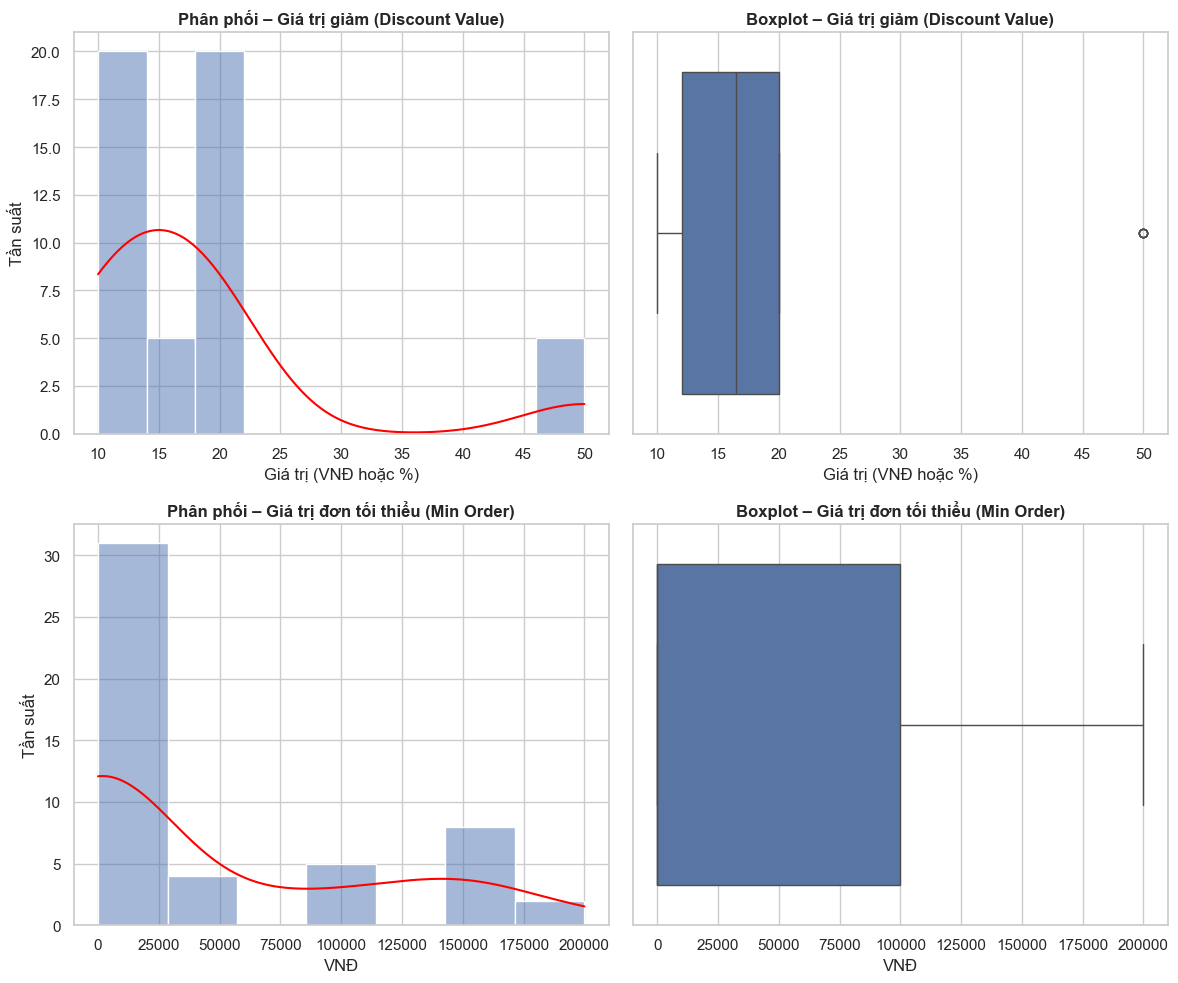

In [22]:
col_config = {
    'discount_value':  {'title': 'Giá trị giảm (Discount Value)', 'xlabel': 'Giá trị (VNĐ hoặc %)'},
    'min_order_value': {'title': 'Giá trị đơn tối thiểu (Min Order)', 'xlabel': 'VNĐ'}
}

# Danh sách các cột cần vẽ
con_cols_names = ['discount_value', 'min_order_value']

# 3. Hàm vẽ biểu đồ phân phối (Histogram + KDE)
def plot_distribution(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    # Tự động tính số hàng, cột (grid)
    cols = 2  
    rows = math.ceil(n / cols)
    
    plt.figure(figsize=(6 * cols, 5 * rows))
    
    for i, col_name in enumerate(con_cols_names, 1):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})
        plt.subplot(rows, cols, i)
        sns.histplot(df[col_name].dropna(), kde=True)
        plt.title(f"Phân phối - {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel("Tần suất")
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ phân phối tại: {save_path}")
        
    plt.show()

# 4. Hàm vẽ kết hợp Distribution và Boxplot
def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    plt.figure(figsize=(12, 5 * n))
    
    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})

        # Distribution plot
        plt.subplot(n, 2, i * 2 + 1)
        ax = sns.histplot(df[col_name].dropna(), kde=True)
        # Thêm kiểm tra tránh lỗi nếu KDE không vẽ được
        if ax.lines:
            ax.lines[0].set_color('red')
            
        plt.title(f"Phân phối – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel('Tần suất')
        
        # Box plot
        plt.subplot(n, 2, i * 2 + 2)
        sns.boxplot(x=df[col_name].dropna())
        plt.title(f"Boxplot – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ kết hợp tại: {save_path}")
        
    plt.show()

# 5. Gọi hàm thực thi và lưu ảnh
# plot_distribution(promotions_df, con_cols_names, save_path='distribution_promotions.png')
plot_distribution_boxplot(promotions_df, con_cols_names, save_path='distribution_boxplot_promotions.png')

In [23]:
promotions_df['discount_value'].value_counts()

discount_value
12.00    10
18.00    10
10.00    10
20.00    10
50.00     5
15.00     5
Name: count, dtype: int64

In [24]:
promotions_df['min_order_value'].value_counts()

min_order_value
0         31
150000     8
100000     5
50000      4
200000     2
Name: count, dtype: int64

#### b. Thống kê mô tả 

In [25]:
promotions_df[['discount_value', 'min_order_value']].describe()

,discount_value,min_order_value
count,50.00,50.00
mean,18.50,46000.00
std,11.24,66116.78
min,10.00,0.00
25%,12.00,0.00
50%,16.50,0.00
75%,20.00,100000.00
max,50.00,200000.00


**Nhận xét:**

- **Quan sát:**
  - Giá trị giảm (Discount Value): Dữ liệu phân bố tập trung chủ yếu ở mức 10 - 20 (VNĐ hoặc %), chiếm tần suất cao nhất với hai đỉnh rõ rệt ở khoảng 10-15 và 15-20. Biểu đồ Boxplot cho thấy trung vị nằm ở mức 15, khoảng tứ phân vị (IQR) hẹp từ khoảng 12 đến 20. Có xuất hiện một điểm dữ liệu ngoại lai (outlier) nằm cách biệt ở mức 50.
  - Giá trị đơn tối thiểu (Min Order): Phân bố lệch phải (right-skewed) rất mạnh. Hơn 30 quan sát tập trung ở khoảng giá trị rất thấp (0 - 25.000 VNĐ). Tần suất giảm dần ở các mức cao hơn nhưng lại xuất hiện các cụm nhỏ ở mốc 100.000 VNĐ và 150.000 - 175.000 VNĐ. Boxplot thể hiện dải dữ liệu trải rất rộng, dải râu kéo dài đến mốc 200.000 VNĐ.

- **Insights:**
  - Về Giá trị giảm: Chiến lược khuyến mãi của danh mục này khá thận trọng và an toàn, chủ yếu áp dụng mức giảm nhỏ đến trung bình (10-20) để kích cầu thường xuyên nhưng vẫn bảo vệ được biên lợi nhuận. Mức giảm sâu 50 hiếm khi xảy ra (outlier), khả năng cao chỉ dành cho các chương trình xả kho (clearance sale) hoặc Flash Sale chớp nhoáng.
  - Về Giá trị đơn tối thiểu: Đa số các chương trình/mã giảm giá có rào cản rất thấp (gần 0 VNĐ), cho thấy mục tiêu chính là thúc đẩy tỷ lệ chuyển đổi (conversion rate) và khuyến khích khách hàng mới ra quyết định mua hàng nhanh chóng. 
  - Các mốc giá trị đơn tối thiểu cao hơn (100.000 VNĐ và 150.000 VNĐ) đóng vai trò làm công cụ kích thích bán chéo (cross-sell) hoặc bán thêm (upsell) nhằm tăng giá trị trung bình trên mỗi đơn hàng (AOV). 
  - Do dữ liệu có sự phân tán mạnh và tồn tại giá trị ngoại lai, khi đưa hai biến này vào các mô hình dự báo học máy (Machine Learning), cần cân nhắc việc xử lý ngoại lai (ví dụ với mức giảm 50) hoặc biến đổi phân phối (Log transform cho Min Order) để mô hình hội tụ tốt hơn.

- **Gợi ý hành động:**
  - Phân tích sâu mức độ hiệu quả (ROI): So sánh tỷ lệ sử dụng (redemption rate) và lợi nhuận ròng giữa nhóm mã giảm giá không yêu cầu Min Order (0 - 25k) và nhóm có Min Order cao (100k, 150k) để tìm ra mức rào cản tối ưu nhất.
  - Tối ưu hóa các "bậc thang" Min Order: Khoảng trống từ 25.000 VNĐ đến 100.000 VNĐ khá lớn. Có thể thử nghiệm (A/B Testing) thêm các mốc yêu cầu đơn tối thiểu ở mức giữa (ví dụ 50.000 VNĐ hoặc 75.000 VNĐ) để xem khách hàng có dễ dàng chi tiêu thêm để đạt ngưỡng hay không.
  - Kiểm soát ngân sách cho các Outliers: Theo dõi chặt chẽ chi phí marketing cho nhóm giảm giá 50 để đảm bảo không bị lạm dụng, đồng thời đo lường xem mức giảm sâu này có thực sự mang lại lượng khách hàng mới chất lượng hay không.

### 1.1.2. Biến phân loại (Categorical)

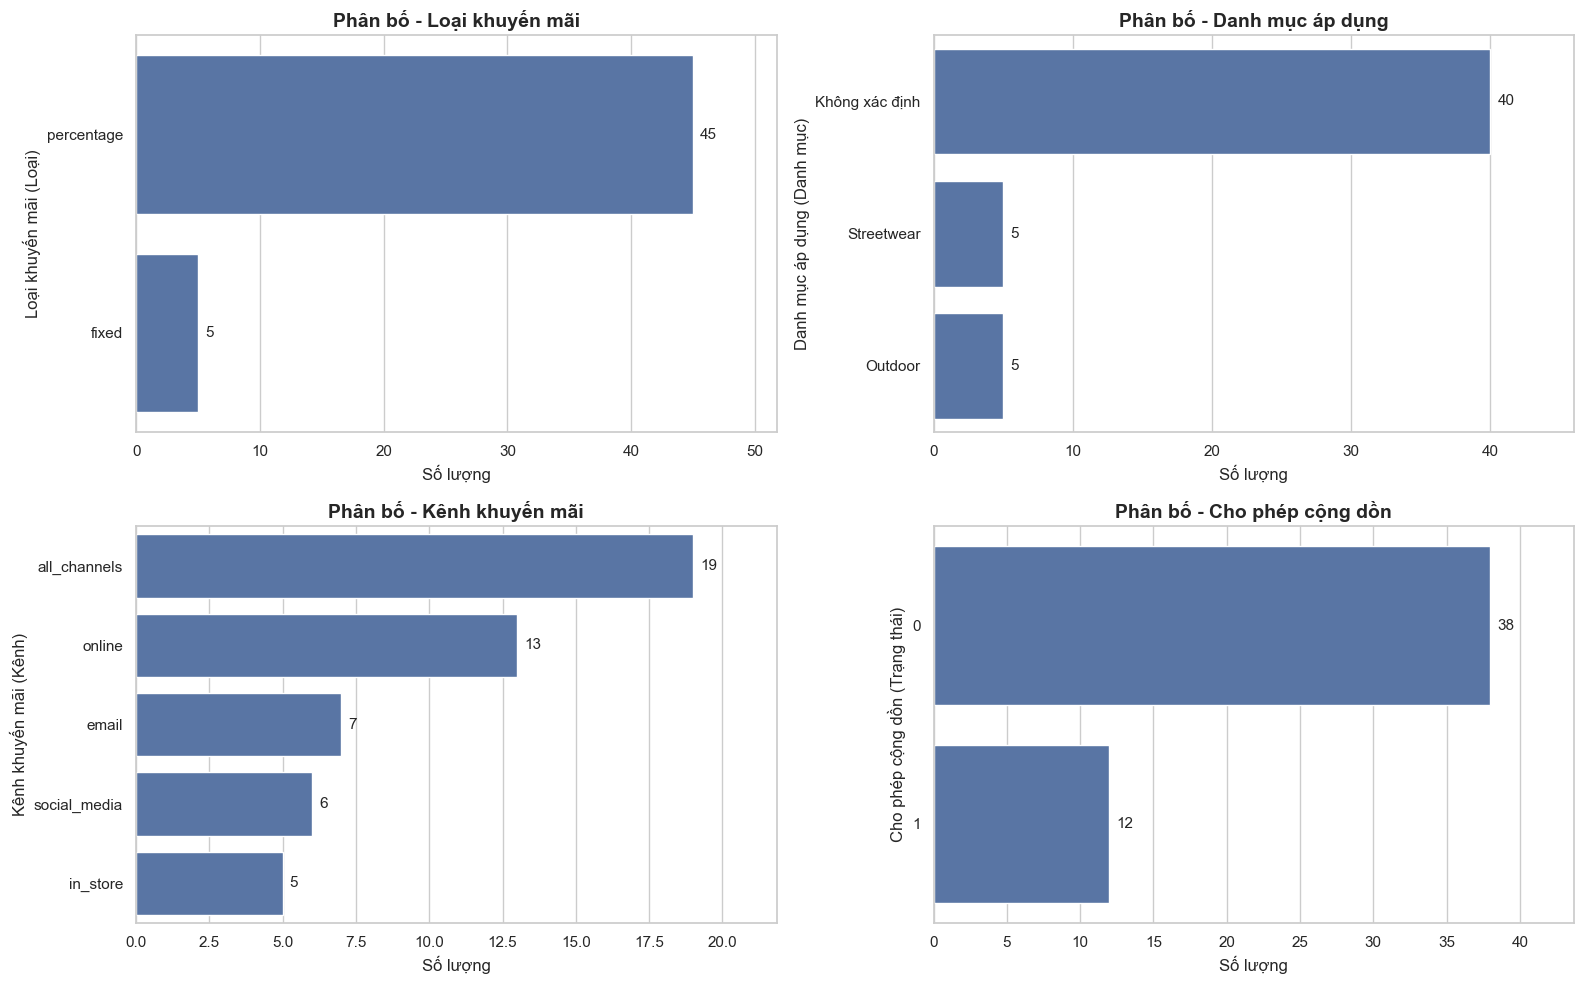

In [26]:
# 1. Cập nhật Từ điển thông tin cột dựa trên promotions.csv
COL_INFO = {
    'promo_type': {'name': 'Loại khuyến mãi', 'unit': 'Loại'},
    'applicable_category': {'name': 'Danh mục áp dụng', 'unit': 'Danh mục'},
    'promo_channel': {'name': 'Kênh khuyến mãi', 'unit': 'Kênh'},
    'stackable_flag': {'name': 'Cho phép cộng dồn', 'unit': 'Trạng thái'}
}

# 2. Hàm vẽ biểu đồ phân bố Categorical (Bar chart ngang)
def plot_horizontal_bar_chart(df, cate_cols_names):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    # Thiết lập kích thước: Tăng chiều ngang để có không gian cho số liệu
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows)) 
    axes = axes.flatten()

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]
        
        if col_name in df.columns:
            # Lấy tần suất xuất hiện, điền 'Không xác định' cho các giá trị bị thiếu (NaN)
            val_counts = df[col_name].fillna('Không xác định').value_counts()
            
            # Xử lý: Lấy top 9, nhóm phần còn lại thành 'Khác'
            if len(val_counts) > 10:
                top9 = val_counts.iloc[:9]
                other_sum = val_counts.iloc[9:].sum()
                plot_data = pd.concat([top9, pd.Series({'Khác': other_sum})])
            else:
                plot_data = val_counts
                
            # Đảm bảo index là kiểu chuỗi
            plot_data.index = plot_data.index.astype(str)
            
            # Vẽ Bar chart ngang (Thêm palette viridis cho sinh động)
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)
            
            # Lấy thông tin Tên và Đơn vị từ Từ điển
            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'Loại'}) 
            
            # Cài đặt tiêu đề và nhãn
            ax.set_title(f"Phân bố - {info['name']}", fontsize=14, fontweight='bold')
            ax.set_xlabel("Số lượng", fontsize=12)
            ax.set_ylabel(f"{info['name']} ({info['unit']})", fontsize=12)
            
            # Thêm con số thực tế bên phải mỗi thanh bar
            for p in ax.patches:
                width = p.get_width()
                if width > 0:
                    ax.annotate(f'{int(width)}', 
                                (width, p.get_y() + p.get_height() / 2.), 
                                ha='left', va='center', fontsize=11, 
                                xytext=(5, 0), textcoords='offset points')
            
            # Mở rộng giới hạn trục x thêm 15% để số liệu (annotate) không bị che khuất
            ax.set_xlim(0, max(plot_data.values) * 1.15)
            
        else:
            ax.set_visible(False)
            
    # Ẩn các trục không sử dụng nếu số lượng cột là số lẻ
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show() # Trả lại plt.show() cho môi trường local của bạn

# 3. Lựa chọn các cột phân loại để vẽ
cate_cols_names = ['promo_type', 'applicable_category', 'promo_channel', 'stackable_flag']

# Thực thi hàm
plot_horizontal_bar_chart(promotions_df, cate_cols_names)

**Nhận xét:**

- **Quan sát:**
  - **Loại khuyến mãi:** Dữ liệu cho thấy sự chênh lệch rất lớn, hình thức giảm theo phần trăm (`percentage`) chiếm ưu thế tuyệt đối với 45 chương trình, trong khi giảm giá cố định (`fixed`) chỉ có 5 chương trình.
  - **Danh mục áp dụng:** Phần lớn các khuyến mãi (40) rơi vào nhóm "Không xác định", mức độ áp dụng cho các danh mục cụ thể rất thấp (Streetwear và Outdoor chỉ có 5 chương trình cho mỗi loại).
  - **Kênh khuyến mãi:** Sự phân bổ tập trung chủ yếu vào nhóm diện rộng như đa kênh (`all_channels`) với 19 chương trình và trực tuyến (`online`) với 13 chương trình. Các kênh đặc thù có tần suất thấp và khá đồng đều: `email` (7), `social_media` (6) và tại cửa hàng `in_store` (5).
  - **Cho phép cộng dồn:** Đa số các khuyến mãi (38 chương trình) mang trạng thái `0` (không cho phép cộng dồn). Chỉ có 12 chương trình (trạng thái `1`) cho phép áp dụng chung với các ưu đãi khác.

- **Insights:**
  - **Về Loại khuyến mãi:** Doanh nghiệp đang thiên vị rõ rệt chiến lược giảm giá theo phần trăm. Đây là thủ thuật tâm lý giá (psychological pricing) phổ biến để kích thích thị giác khách hàng bằng những con số lớn (ví dụ: giảm 20%, 30% nghe có vẻ hấp dẫn hơn là giảm một số tiền cụ thể), đồng thời linh hoạt theo giá trị đơn hàng.
  - **Về Danh mục & Kênh:** Mức độ phủ sóng của các chương trình khuyến mãi rất rộng (Đa kênh, Online, Danh mục Không xác định - có thể là áp dụng toàn gian hàng). Điều này cho thấy giai đoạn hiện tại, chiến lược tập trung vào việc kích cầu tổng thể và tăng volume giao dịch thay vì đẩy mạnh bán chéo cho một ngách sản phẩm hay nền tảng cụ thể.
  - **Về Chính sách cộng dồn:** Việc quản lý rủi ro biên lợi nhuận được thực hiện rất chặt chẽ. Bằng cách chặn cộng dồn ở hầu hết các mã, doanh nghiệp tránh được các "lỗ hổng" săn sale làm xói mòn lợi nhuận.
  - **Về Chất lượng dữ liệu:** Lượng lớn (40) dữ liệu nằm ở danh mục "Không xác định" cho thấy có vấn đề trong quy trình gắn thẻ (tagging) hệ thống khuyến mãi, điều này sẽ làm mù mờ khả năng đánh giá hiệu quả (ROI) của từng ngành hàng.

- **Gợi ý hành động:**
  - **Cải thiện chất lượng dữ liệu (Data Quality):** Cần rà soát và chuẩn hóa lại quy trình thiết lập mã khuyến mãi trên hệ thống. Hạn chế tối đa việc để trống hoặc gán nhãn "Không xác định" cho danh mục để thuận lợi cho việc khai phá dữ liệu (Data Mining) và đánh giá chiến dịch sau này.
  - **Thử nghiệm phân khúc kênh:** `email` và `social_media` đang chiếm tỷ trọng thấp. Có thể thiết kế các mã khuyến mãi độc quyền (Exclusive Promo) riêng cho các kênh này và thực hiện A/B Testing để đo lường tỷ lệ chuyển đổi, nhằm tối ưu hóa chi phí thu hút khách hàng (CAC) trên từng điểm chạm.
  - **Tối ưu hóa "Fixed" vs "Percentage":** Chạy phân tích chéo (Cross-tabulation) với giá trị đơn hàng trung bình (AOV). Thông thường, với các sản phẩm giá trị cao (như áo khoác Outdoor cao cấp), mã `fixed` (ví dụ: Giảm ngay 200K) lại mang hiệu ứng tốt hơn `percentage`. Có thể đa dạng hóa loại mã tùy theo phân khúc giá sản phẩm.

### 1.1.3. Biến thời gian 

In [27]:
import matplotlib.dates as mdates

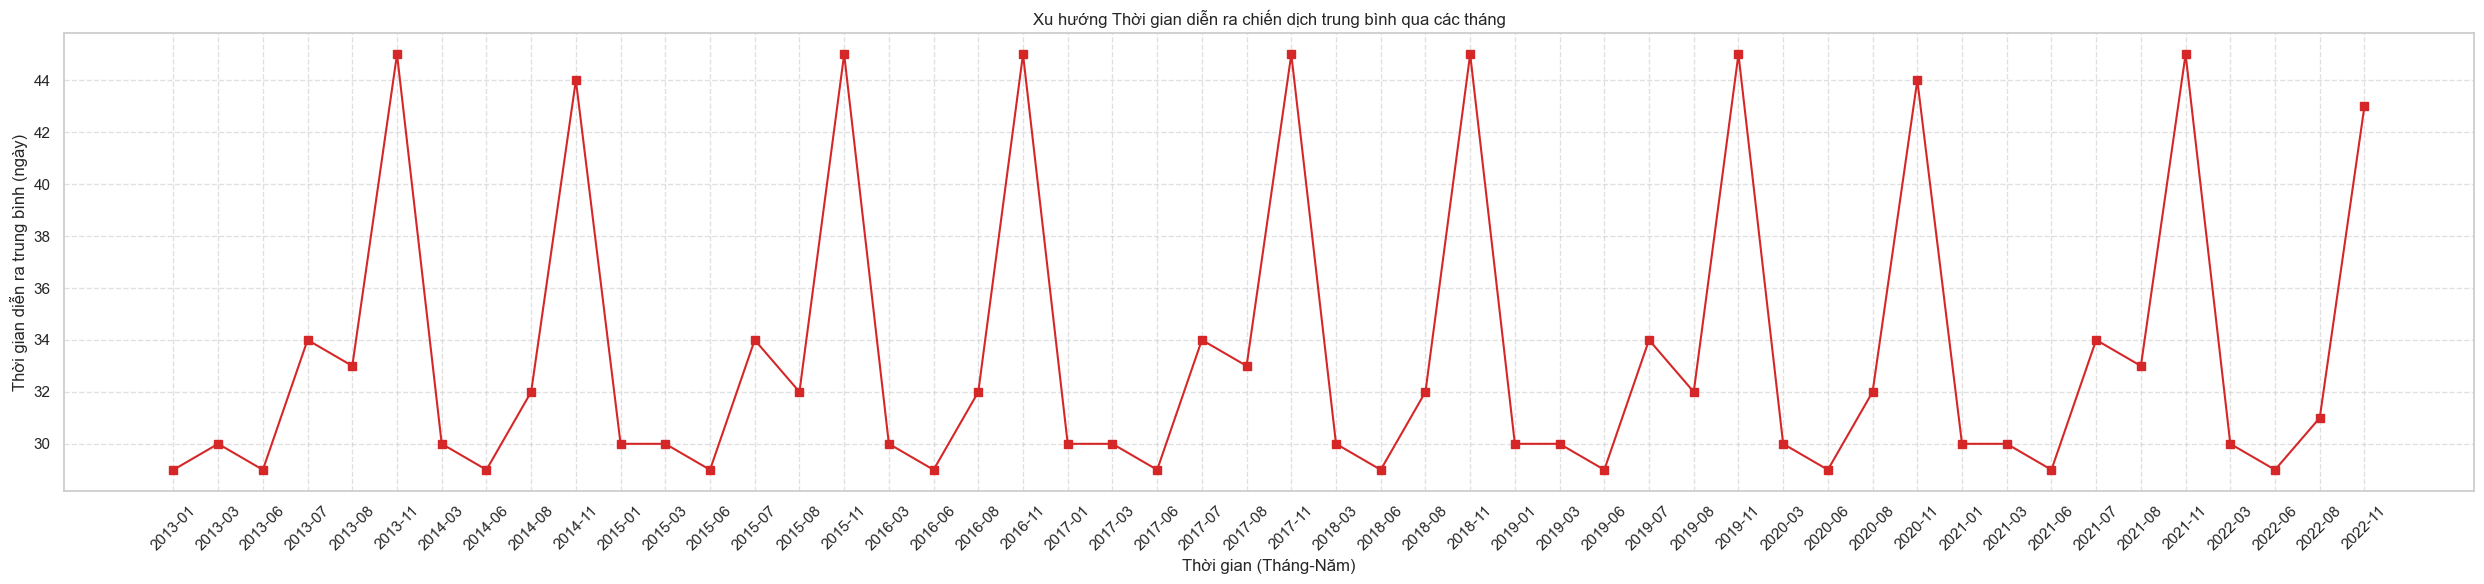

In [28]:
# Chuyển đổi cột start_date và end_date sang định dạng datetime
promotions_df['start_date'] = pd.to_datetime(promotions_df['start_date'])
promotions_df['end_date'] = pd.to_datetime(promotions_df['end_date'])

# Tính thời gian diễn ra chiến dịch (số ngày)
promotions_df['duration_days'] = (promotions_df['end_date'] - promotions_df['start_date']).dt.days

# Tạo cột 'year_month' để nhóm dữ liệu theo từng tháng
promotions_df['year_month'] = promotions_df['start_date'].dt.to_period('M')

# Tổng hợp dữ liệu: Chỉ cần tính số ngày trung bình mỗi tháng
trend_df = promotions_df.groupby('year_month').agg(
    avg_duration=('duration_days', 'mean')
).reset_index()

# Chuyển đổi chuỗi tháng-năm để hiển thị đẹp hơn trên trục X
trend_df['year_month'] = trend_df['year_month'].astype(str)
trend_df = trend_df.sort_values('year_month')

fig, ax = plt.subplots(figsize=(25, 6))

# Vẽ xu hướng Thời gian kéo dài trung bình
color = 'tab:red'
ax.set_xlabel('Thời gian (Tháng-Năm)')
ax.set_ylabel('Thời gian diễn ra trung bình (ngày)')
# Đổi nét đứt '--' thành nét liền '-' cho dễ nhìn khi chỉ có 1 đường
ax.plot(trend_df['year_month'], trend_df['avg_duration'], color=color, marker='s', linestyle='-', label='Thời gian TB (ngày)')
ax.tick_params(axis='y')
ax.tick_params(axis='x', rotation=45) # Xoay nhãn trục x để không bị chồng chéo
ax.grid(True, linestyle='--', alpha=0.6)

# Cập nhật lại tiêu đề
plt.title('Xu hướng Thời gian diễn ra chiến dịch trung bình qua các tháng')
fig.tight_layout()
plt.show()

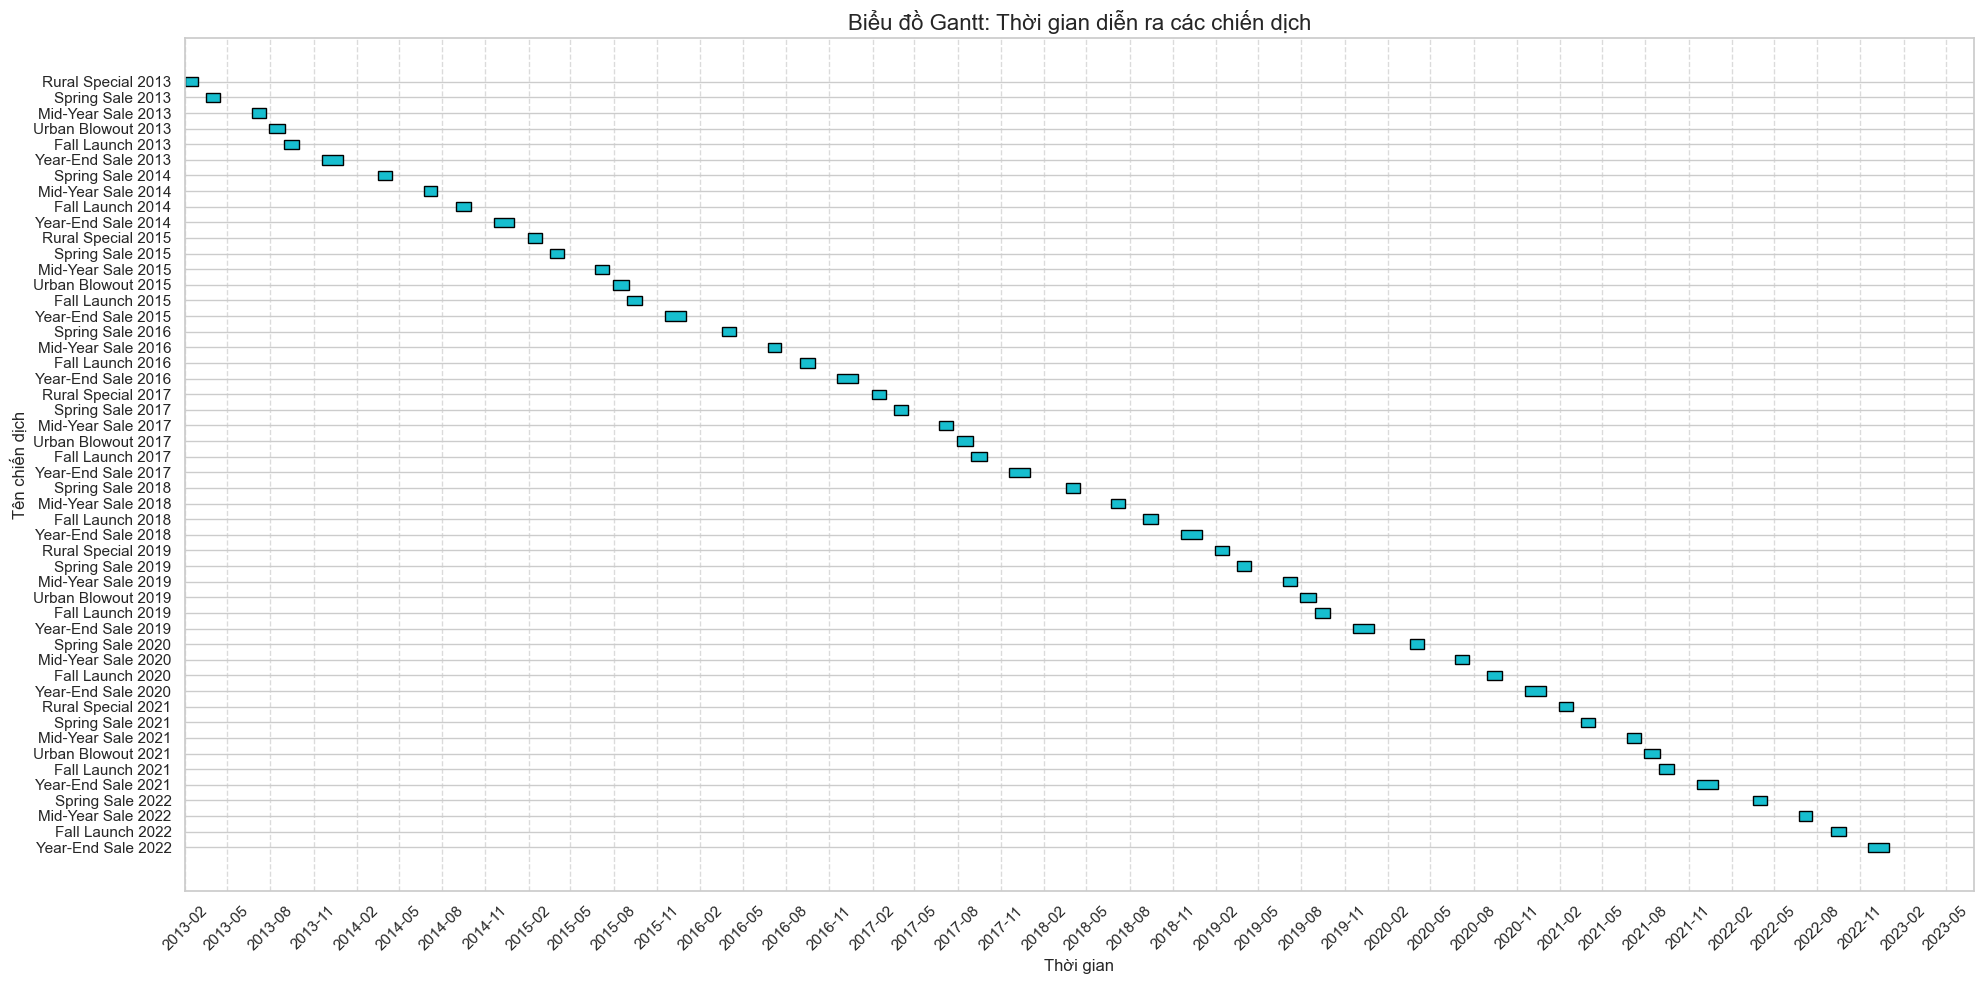

In [29]:
promotions_df['start_date'] = pd.to_datetime(promotions_df['start_date'])
promotions_df['end_date'] = pd.to_datetime(promotions_df['end_date'])

# Sắp xếp các chiến dịch theo ngày bắt đầu để biểu đồ có tính thứ tự (từ trái qua phải)
promotions_df = promotions_df.sort_values(by='start_date', ascending=True).reset_index(drop=True)

# Tính toán thời gian kéo dài của mỗi chiến dịch (đóng vai trò là chiều dài của thanh biểu đồ)
promotions_df['duration_days'] = (promotions_df['end_date'] - promotions_df['start_date']).dt.days

fig, ax = plt.subplots(figsize=(20, 10))

# Vẽ biểu đồ Gantt bằng cách sử dụng barh (biểu đồ cột ngang)
# Tham số 'left' là điểm bắt đầu của thanh (start_date)
# Tham số 'width' là độ dài của thanh (duration_days)
bars = ax.barh(y=promotions_df['promo_name'], 
               width=promotions_df['duration_days'], 
               left=promotions_df['start_date'], 
               color='tab:cyan', 
               edgecolor='black', 
               height=0.6)

# Định dạng và trang trí biểu đồ
ax.set_xlabel('Thời gian')
ax.set_ylabel('Tên chiến dịch')
ax.set_title('Biểu đồ Gantt: Thời gian diễn ra các chiến dịch', fontsize=16)

# Định dạng trục X hiển thị thời gian (Năm-Tháng) thay vì số ngày
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# Hiển thị mốc thời gian cách nhau mỗi 3 tháng để tránh bị rối mắt
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)) 
plt.xticks(rotation=45)

# Đảo ngược trục Y để chiến dịch diễn ra sớm nhất nằm ở trên cùng
ax.invert_yaxis()

# Thêm lưới dọc để dễ gióng mốc thời gian
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - **Biểu đồ xu hướng (Line Chart):** Thời gian trung bình của các chiến dịch dao động chủ yếu ở mức cơ sở từ 29 - 34 ngày (khoảng 1 tháng). Dữ liệu thể hiện tính chu kỳ cực kỳ rõ rệt với các đỉnh nhọn (spikes) vọt lên mức 44 - 45 ngày (khoảng 1.5 tháng). Các đỉnh này xuất hiện đều đặn, thường rơi vào các tháng cuối quý 3 (tháng 8) hoặc quý 4 (tháng 11) và có xu hướng luân phiên nhau qua các năm.
  - **Biểu đồ Gantt:** Lịch trình chạy chiến dịch tuân theo một khuôn mẫu cố định và lặp lại hàng năm (từ 2013 đến 2022) với cấu trúc tuần tự: *Rural Special -> Spring Sale -> Mid-Year Sale -> Urban Blowout -> Fall Launch -> Year-End Sale*. Hầu hết các khối chiến dịch không có sự gối đầu (overlap) lên nhau, dứt điểm chiến dịch này mới chuyển sang chiến dịch tiếp theo.

- **Insights:**
  - **Mô hình vận hành chuẩn hóa (Standardization):** Việc duy trì thời lượng baseline quanh mốc 30 ngày cho thấy đội ngũ Marketing và Vận hành quản lý campaign theo block hàng tháng (Monthly Basis). Điều này giúp dễ dàng kiểm soát chi phí, phân bổ tồn kho và báo cáo KPI một cách rành mạch.
  - **Chiến lược Campaign Trọng điểm (Mega Campaigns):** Các chu kỳ kéo dài 44-45 ngày chính là những đợt "Big Sale" định kỳ (thường rơi vào mùa mua sắm cuối năm hoặc xả hàng giữa năm). Thời gian kéo dài giúp tối đa hóa khả năng tiếp cận khách hàng và xử lý lượng lớn hàng hóa.
  - **Phòng tránh hiệu ứng "Cannibalization" (Tự ăn thịt doanh thu):** Biểu đồ Gantt cho thấy các sự kiện nối tiếp nhau rất gọn gàng, không chồng chéo. Đây là chiến lược tốt để khách hàng không bị bối rối bởi quá nhiều thông điệp khuyến mãi cùng lúc, đồng thời bảo vệ biên lợi nhuận của từng đợt sale.
  - **Tính dễ đoán (Predictability):** Mặc dù tạo ra nhịp độ ổn định, nhưng lịch trình lặp lại quá máy móc trong suốt 10 năm có thể khiến tệp khách hàng cũ "bắt bài" (ví dụ: họ sẽ đợi đến tháng 8 hoặc tháng 11 để mua hàng thay vì mua ở các tháng có campaign nhỏ), làm giảm hiệu suất của các tháng còn lại.

- **Gợi ý hành động:**
  - **Đánh giá "Burn-out" của Mega Campaigns:** Phân tích chuỗi thời gian (Time-series Analysis) đối với doanh thu hàng ngày của các chiến dịch 45 ngày. Nếu phần lớn doanh thu chỉ tập trung ở 2 tuần đầu và 3 ngày cuối, việc kéo dài tới 1.5 tháng đang gây lãng phí ngân sách duy trì (Ads/Operation). Cân nhắc rút ngắn xuống còn 21-30 ngày để tạo cảm giác cấp bách (FOMO - Fear Of Missing Out).
  - **Phá vỡ tính chu kỳ để kích cầu:** Khách hàng có thể đang quen với việc chờ đợi các mốc tháng 8 hoặc tháng 11. Đội ngũ có thể tung ra các "Surprise Flash Sale" ngắn ngày (3-5 ngày) vào các tháng trũng (như tháng 3, tháng 6) để kích thích nhóm khách hàng không có ý định mua sắm từ trước.
  - **Tối ưu hóa các khoảng trống (Gap):** Dựa vào biểu đồ Gantt, có những khoảng nghỉ ngắn giữa các chiến dịch. Cần đo lường lượng truy cập tự nhiên (Organic Traffic) trong các khoảng Gap này. Nếu traffic giảm sâu, có thể áp dụng các chương trình duy trì tương tác (Gamification, tích điểm) thay vì giảm giá trực tiếp để giữ chân người dùng trên nền tảng.

#### a. Phân tích phân phối theo tháng trong năm

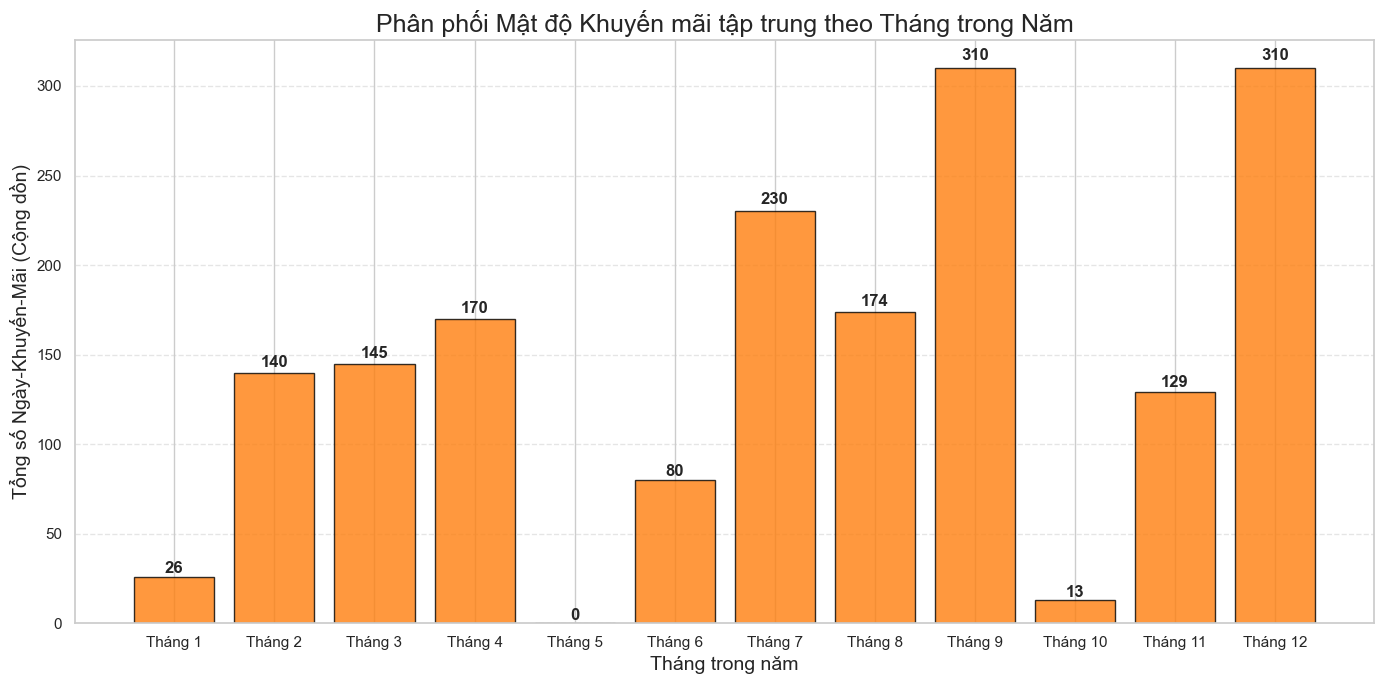

In [32]:
promotions_df['start_date'] = pd.to_datetime(promotions_df['start_date'])
promotions_df['end_date'] = pd.to_datetime(promotions_df['end_date'])

# Tạo chuỗi ngày từ min_date đến max_date
min_date = promotions_df['start_date'].min()
max_date = promotions_df['end_date'].max()
date_range = pd.date_range(min_date, max_date)

# Đếm số lượng CTKM diễn ra trong mỗi ngày
active_counts = []
for d in date_range:
    count = ((promotions_df['start_date'] <= d) & (promotions_df['end_date'] >= d)).sum()
    active_counts.append({'Date': d, 'active_count': count})

daily_df = pd.DataFrame(active_counts)

# Trích xuất tháng từ ngày
daily_df['month'] = daily_df['Date'].dt.month

# Nhóm theo 12 tháng và tính tổng số 'ngày-khuyến-mãi'
monthly_dist = daily_df.groupby('month')['active_count'].sum().reset_index()

months_label = ['Tháng 1', 'Tháng 2', 'Tháng 3', 'Tháng 4', 'Tháng 5', 'Tháng 6', 
                'Tháng 7', 'Tháng 8', 'Tháng 9', 'Tháng 10', 'Tháng 11', 'Tháng 12']
monthly_dist['month_name'] = months_label

plt.figure(figsize=(14, 7))
bars = plt.bar(monthly_dist['month_name'], monthly_dist['active_count'], 
               color='tab:orange', edgecolor='black', alpha=0.8)

# Vòng lặp này giúp hiển thị con số trực tiếp lên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.01), int(yval), 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Phân phối Mật độ Khuyến mãi tập trung theo Tháng trong Năm', fontsize=18)
plt.xlabel('Tháng trong năm', fontsize=14)
plt.ylabel('Tổng số Ngày-Khuyến-Mãi (Cộng dồn)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

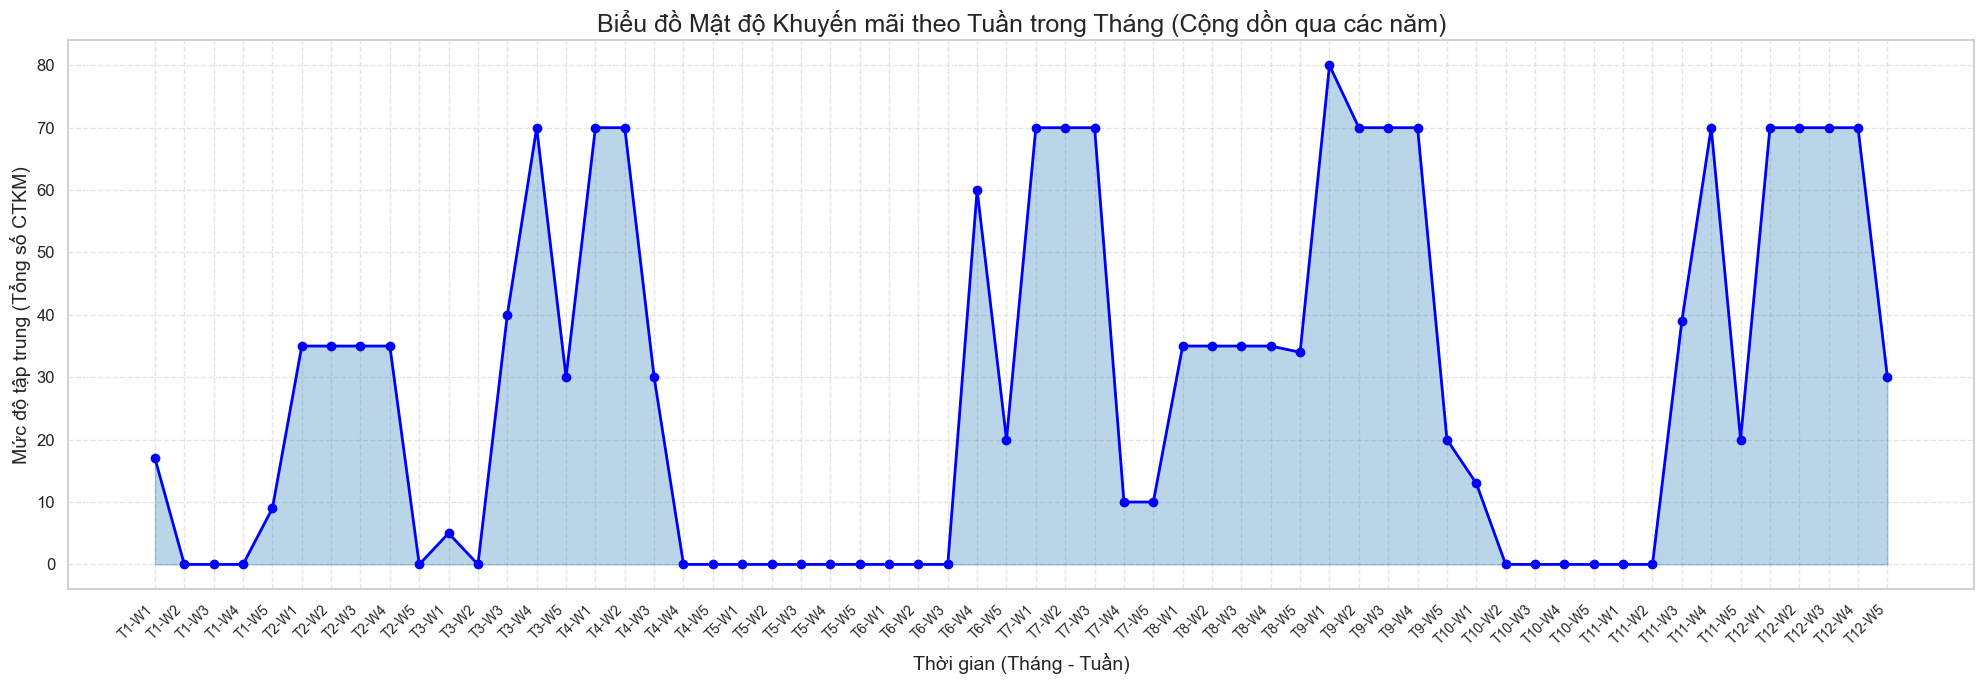

In [35]:
promotions_df['start_date'] = pd.to_datetime(promotions_df['start_date'])
promotions_df['end_date'] = pd.to_datetime(promotions_df['end_date'])

min_date = promotions_df['start_date'].min()
max_date = promotions_df['end_date'].max()
date_range = pd.date_range(min_date, max_date)

active_counts = []
for d in date_range:
    count = ((promotions_df['start_date'] <= d) & (promotions_df['end_date'] >= d)).sum()
    active_counts.append({'Date': d, 'active_count': count})

daily_df = pd.DataFrame(active_counts)

# Trích xuất Tháng và Ngày trong tháng
daily_df['month'] = daily_df['Date'].dt.month
daily_df['day_of_month'] = daily_df['Date'].dt.day

# Tính Tuần trong tháng (Tuần 1: 1-7, Tuần 2: 8-14, Tuần 3: 15-21, Tuần 4: 22-28, Tuần 5: 29+)
daily_df['week_of_month'] = (daily_df['day_of_month'] - 1) // 7 + 1

# Gom nhóm theo 'month' và 'week_of_month', tính tổng số lượng CTKM
weekly_dist = daily_df.groupby(['month', 'week_of_month'])['active_count'].sum().reset_index()

# Tạo nhãn trục X cho gọn (Ví dụ: T1-W1 nghĩa là Tháng 1 - Tuần 1)
weekly_dist['label_short'] = 'T' + weekly_dist['month'].astype(str) + '-W' + weekly_dist['week_of_month'].astype(str)

plt.figure(figsize=(20, 7))

# Tạo dãy số X từ 0 đến n để chia khoảng cách đều nhau
x_positions = range(len(weekly_dist))

# Vẽ vùng đổ màu
plt.fill_between(x_positions, weekly_dist['active_count'], color='tab:blue', alpha=0.3)
# Vẽ đường kết hợp chấm (marker) để dễ quan sát số liệu của từng tuần
plt.plot(x_positions, weekly_dist['active_count'], color='blue', marker='o', markersize=6, linewidth=2)

# Chỉnh sửa nhãn trục X
plt.xticks(ticks=x_positions, labels=weekly_dist['label_short'], rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=12)

plt.title('Biểu đồ Mật độ Khuyến mãi theo Tuần trong Tháng (Cộng dồn qua các năm)', fontsize=18)
plt.xlabel('Thời gian (Tháng - Tuần)', fontsize=14)
plt.ylabel('Mức độ tập trung (Tổng số CTKM)', fontsize=14)

# Thêm lưới để gióng tọa độ dễ dàng hơn
plt.grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

In [ ]:
# Đếm số chiến dịch theo năm
promotions_df['start_date'] = pd.to_datetime(promotions_df['start_date'], errors='coerce')

campaigns_by_year = (
    promotions_df
    .dropna(subset=['start_date'])
    .assign(year=promotions_df['start_date'].dt.year)
    .groupby('year')
    .agg(so_chien_dich=('promo_name', 'count'))
    .reset_index()
    .sort_values('year')
)

display(campaigns_by_year)
